In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
df = pd.read_excel(r'C:Downloads\DatasetP2')

# EDA

In [63]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [66]:
df.shape

(1200, 14)

In [67]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [87]:
df.drop('CouponCode', axis=1, inplace=True)

In [89]:
df.isnull().sum()

Date              0
Product           0
Quantity          0
UnitPrice         0
PaymentMethod     0
OrderStatus       0
ItemsInCart       0
ReferralSource    0
TotalPrice        0
dtype: int64

# No Null Values

In [88]:
df.duplicated().sum()

np.int64(0)

# No duplicates

# Data Reduction

In [69]:
# remove columns
df.drop(columns=['OrderID','CustomerID','TrackingNumber','ShippingAddress'], inplace=True)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1200 non-null   datetime64[ns]
 1   Product         1200 non-null   object        
 2   Quantity        1200 non-null   int64         
 3   UnitPrice       1200 non-null   float64       
 4   PaymentMethod   1200 non-null   object        
 5   OrderStatus     1200 non-null   object        
 6   ItemsInCart     1200 non-null   int64         
 7   CouponCode      891 non-null    object        
 8   ReferralSource  1200 non-null   object        
 9   TotalPrice      1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 93.9+ KB


In [71]:
df.dtypes

Date              datetime64[ns]
Product                   object
Quantity                   int64
UnitPrice                float64
PaymentMethod             object
OrderStatus               object
ItemsInCart                int64
CouponCode                object
ReferralSource            object
TotalPrice               float64
dtype: object

In [72]:
# change data types 
df['Product'] = df['Product'].astype('category')
df['PaymentMethod'] = df['PaymentMethod'].astype('category')
df['OrderStatus'] = df['OrderStatus'].astype('category')
df['ReferralSource'] = df['ReferralSource'].astype('category')

In [90]:
df.dtypes

Date              datetime64[ns]
Product                 category
Quantity                   int64
UnitPrice                float64
PaymentMethod           category
OrderStatus             category
ItemsInCart                int64
ReferralSource          category
TotalPrice               float64
dtype: object

In [96]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [97]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [75]:
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [76]:
df['TotalPrice'].describe()

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

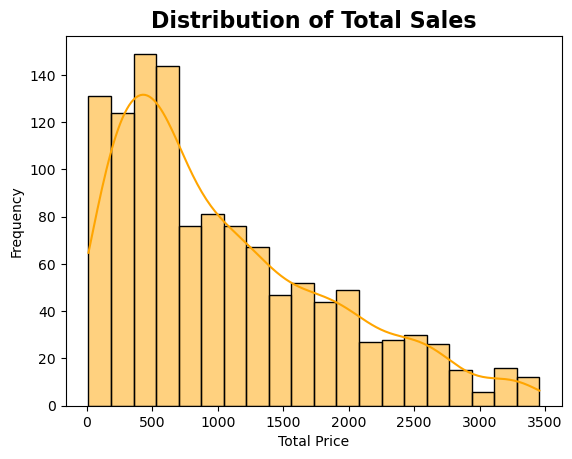

In [104]:
#df['TotalPrice'].plot(kind='hist')
sns.histplot(df['TotalPrice'], bins=20, kde=True, color='orange')

plt.title('Distribution of Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Price')
plt.ylabel('Frequency')

plt.show()

In [78]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].median()

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

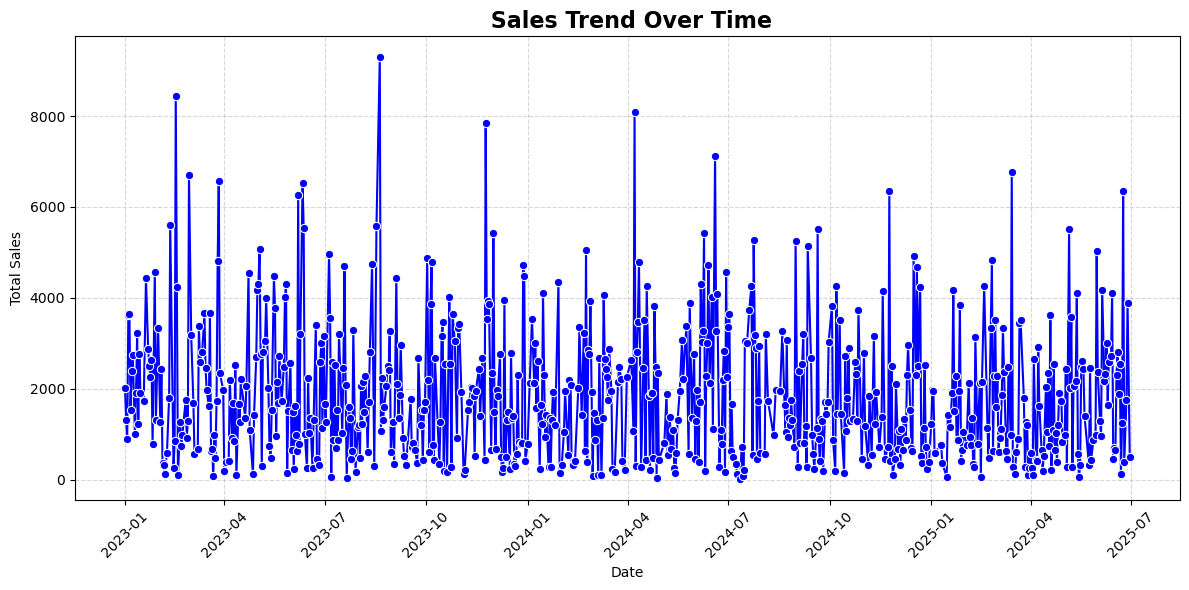

In [110]:
plt.figure(figsize=(12,6))
daily_sales = df.groupby('Date')['TotalPrice'].sum().reset_index()
sns.lineplot(data=daily_sales, x='Date', y='TotalPrice', color='blue', marker='o')
plt.title(' Sales Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [109]:
df.groupby('Product', observed=True)['Quantity'].sum().sort_values()

Product
Phone      411
Monitor    480
Tablet     497
Desk       508
Laptop     535
Printer    542
Chair      562
Name: Quantity, dtype: int64

In [108]:
df.groupby('Product', observed=False)['TotalPrice'].sum().sort_values(ascending=False)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

In [82]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

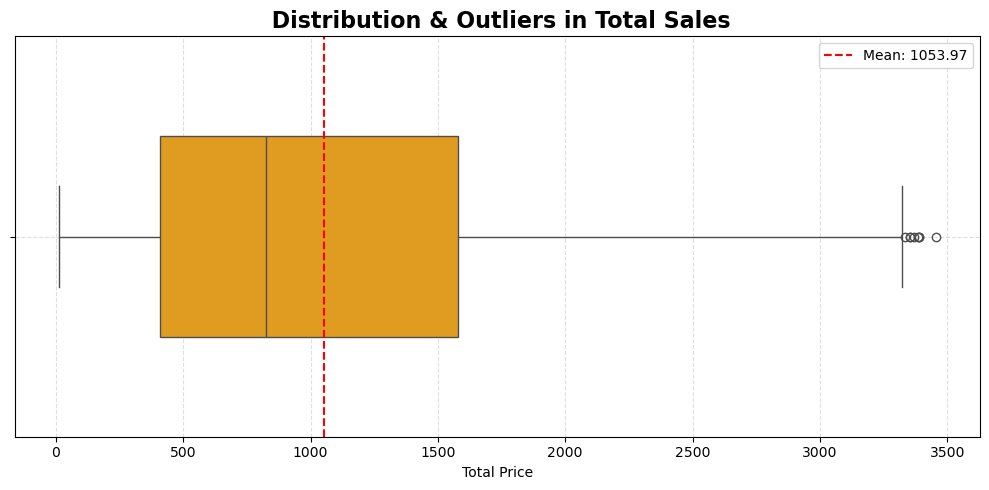

In [107]:
#sns.boxplot(x=df['TotalPrice'])
#plt.show()
plt.figure(figsize=(10,5))

sns.boxplot(x=df['TotalPrice'], color='orange', width=0.5)

plt.title(' Distribution & Outliers in Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Price')

# show mean line manually (optional enhancement)
mean_value = df['TotalPrice'].mean()
plt.axvline(mean_value, color='red', linestyle='--', label=f'Mean: {mean_value:.2f}')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

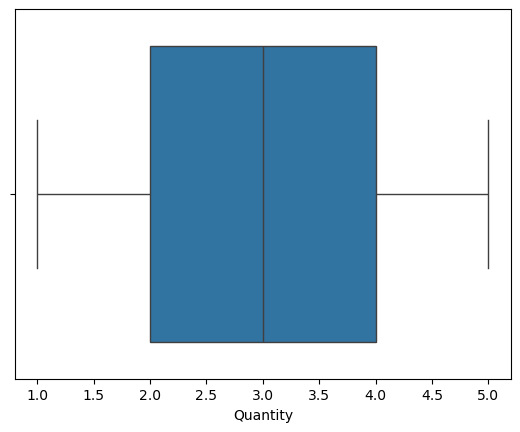

In [84]:
sns.boxplot(x=df['Quantity'])
plt.show()

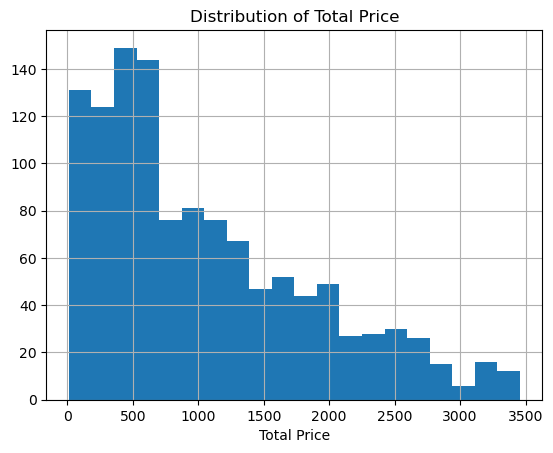

In [85]:
df['TotalPrice'].hist(bins=20)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.show()

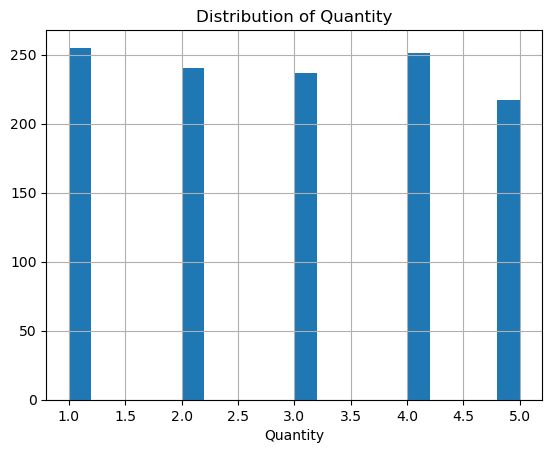

In [86]:
df['Quantity'].hist(bins=20)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.show()

In [111]:
df.groupby('Product', observed=True)['TotalPrice'].sum()

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64

In [114]:
df.groupby('Product', observed=True)['Quantity'].sum()

Product
Chair      562
Desk       508
Laptop     535
Monitor    480
Phone      411
Printer    542
Tablet     497
Name: Quantity, dtype: int64

In [102]:
df.groupby('PaymentMethod')['TotalPrice'].sum()


C:\Users\Lap Heaven\AppData\Local\Temp\ipykernel_6720\1271058608.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('PaymentMethod')['TotalPrice'].sum()


PaymentMethod
Cash           259786.29
Credit Card    263847.63
Debit Card     232361.18
Gift Card      246323.92
Online         262442.94
Name: TotalPrice, dtype: float64

In [103]:
df.groupby('ReferralSource')['TotalPrice'].sum()

C:\Users\Lap Heaven\AppData\Local\Temp\ipykernel_6720\2294037116.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ReferralSource')['TotalPrice'].sum()


ReferralSource
Email        261808.55
Facebook     250410.90
Google       250441.48
Instagram    275285.45
Referral     226815.58
Name: TotalPrice, dtype: float64